In [40]:
#импортируем библиотеки
import pandahouse
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
%matplotlib inline

In [41]:
connection = {
    'host' : 'http://clickhouse.lab.karpov.courses:8123',
    'password' : 'dpo_python_2020',
    'user' : 'student',
    'database' : 'simulator_20260320'
}

Эксперимент проходил с 2026-02-27 по 2026-03-05 включительно. Для эксперимента были задействованы 2 и 1 группы. <br>
1-контрольная группа, 2- использовался новый алгоритм, рекомендующий посты, похожие на те, что уже лайкнуты пользователем.<br>

Основная гипотеза заключается в том, что новый алгоритм во 2-й группе приведет к увеличению CTR. <br>

Наша задача — проанализировать данные А/B-теста. <br>

Сравним CTR в двух группах с помощью:<br>
t-теста, <br>
Пуассоновского бутстрепа, 
<br>теста Манна-Уитни,
<br> t-теста на сглаженном ctr (α=5)<br> 
а также t-теста и теста Манна-Уитни поверх бакетного преобразования).<br>

In [42]:
q = """
SELECT exp_group,
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM {db}.feed_actions
WHERE toDate(time) between '2026-02-27' and '2026-03-05'
    and exp_group in (1,2)
GROUP BY exp_group, user_id
"""
df = pandahouse.read_clickhouse(q, connection=connection)

In [43]:
df

,exp_group,user_id,likes,views,ctr
0,1,109963,3,15,0.200000
1,1,26117,32,141,0.226950
2,1,138232,18,73,0.246575
3,1,26295,39,141,0.276596
4,1,18392,7,32,0.218750
...,...,...,...,...,...
19892,2,17146,0,10,0.000000
19893,1,30872,11,59,0.186441
19894,2,25383,42,127,0.330709
19895,2,139020,17,41,0.414634


In [44]:
#получим данные о количестве пользователей в каждой из групп
df.groupby('exp_group')['user_id'].nunique()

exp_group
1    10020
2     9877
Name: user_id, dtype: int64

### Сравним CTR в двух группах t-тестом

Н<sub>0</sub>: Средние значения CTR у двух выборок равны <br>
Н<sub>1</sub>: Альтернативная гипотеза, средние значения не равны 

In [45]:
stats.ttest_ind(df[df.exp_group==1].ctr, 
                df[df.exp_group==2].ctr,
                equal_var=False)

Ttest_indResult(statistic=0.4051491913112757, pvalue=0.685373331140751)

Видим, что p-value > порога значимости 0.05, у нас нет оснований отклонять нулевую гипотезу. <br>
По результатам t-теста, различия между группами незначимы

In [46]:
 df[df.exp_group==1].ctr.mean(), df[df.exp_group==2].ctr.mean() #разница между средними незначима, среднеи практически совпадают

(0.216773994120072, 0.2161016893237817)

### Сравним CTR в двух группах тестом Манна-Уитни

In [47]:
stats.mannwhitneyu(df[df.exp_group==1].ctr, 
                df[df.exp_group==2].ctr,
                alternative='two-sided')

MannwhitneyuResult(statistic=55189913.0, pvalue=4.632205841806026e-45)

По результатам теста Манна-Уитни, p-value < 0.05, нулевая гипотеза отклоняется. Различия между группами статистически значимы.

### Выполним t-тест на сглаженном ctr (α=5)

Изменим метрику, проведём Лапласовское сглаживание CTR по формуле <br>

$$ smoothedCTR = \frac{like + \alpha*globalCTR}{views + \alpha} $$

In [48]:
#функция, выполняющая сглаживание CTR
def get_smothed_ctr(user_likes, user_views, global_ctr, alpha):
    smothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    return smothed_ctr

#считаем общегрупповой CTR по группам 1 и 2
global_ctr_1 = df[df.exp_group == 1].likes.sum()/df[df.exp_group ==1].views.sum()
global_ctr_2 = df[df.exp_group == 2].likes.sum()/df[df.exp_group ==2].views.sum()

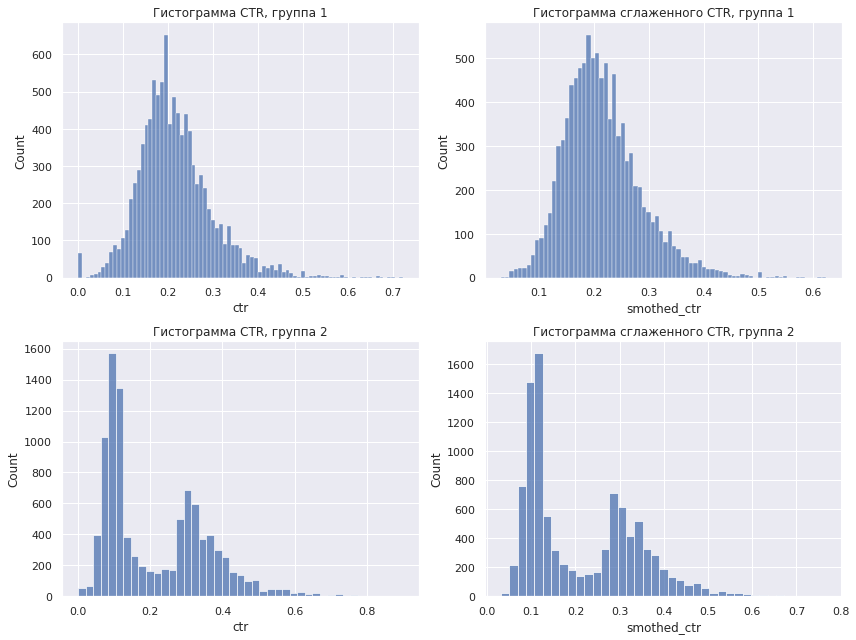

In [49]:
#Визуализируем гистограммы CTR
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Гистограмма обычного CTR в группе 1
group1 = df[df.exp_group == 1].copy()
sns.histplot(group1.ctr, kde = False, ax=axes[0,0])
axes[0,0].set_title("Гистограмма CTR, группа 1")

# Гистограмма сглаженного CTR в группе 1
group1['smothed_ctr'] = df.apply(
   lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_1, 5),
axis=1)
sns.histplot(group1.smothed_ctr, kde = False, ax=axes[0,1])
axes[0,1].set_title("Гистограмма сглаженного CTR, группа 1")

# Гистограмма обычного CTR в группе 2
group2 = df[df.exp_group == 2].copy()
sns.histplot(group2.ctr, kde = False, ax=axes[1,0])
axes[1,0].set_title("Гистограмма CTR, группа 2")

# Гистограмма сглаженного CTR в группе 2
group2['smothed_ctr'] = df.apply(
   lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_2, 5),
axis=1)
sns.histplot(group2.smothed_ctr, kde = False, ax=axes[1,1])
axes[1,1].set_title("Гистограмма сглаженного CTR, группа 2")

plt.tight_layout()
plt.show()

*Рис 1. Гистограммы распределений CTR и сглаженных CTR в группах пользователей 1 и 2*

In [50]:
#выполним t-тест по метрике сглаженного CTR
stats.ttest_ind(group1.smothed_ctr, 
                group2.smothed_ctr,
                equal_var=False)

Ttest_indResult(statistic=1.9460491517027683, pvalue=0.05166679015318526)

p-value > 0.05, Нет оснований отклонить нулевую гипотезу о равенстве средних CTR в группах 1 и 2, различия не значимы

In [51]:
#выполним тест Манна-Уитни по метрике сглаженного CTR
stats.mannwhitneyu(group1.smothed_ctr, 
                group2.smothed_ctr,
                alternative='two-sided')

MannwhitneyuResult(statistic=55528353.0, pvalue=2.396534039374286e-50)

p-value < 0.05, различия между группами статистически значимы

### Применим Пуассоновский бутстреп для подсчета разницы в CTR

1) Возьмём выборку из группы А <br>
2) Из распределения Пуассона сгенерируем «сколько раз этот пользователь попал в псевдовыборку», получим колонку weight1
3) Подсчитаем по каждой псевдовыборке глобальный CTR по формуле
$$ globalCTR = \frac{sum(likes*weight)}{sum(views*weight)} $$
4) То же самое выполним для группы B
5) Вычислим разницу между globalCTR для группы А и В, запишем в массив
6) Действия повторим 2000 раз

In [11]:
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):
    poisson_bootstraps1 = stats.poisson(1).rvs(
      (n_bootstrap, len(likes1))).astype(np.int64)
    poisson_bootstraps2 = stats.poisson(1).rvs(
          (n_bootstrap, len(likes2))).astype(np.int64)
   
    globalCTR1 = (poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)
   
    globalCTR2 = (poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)
    
    return globalCTR1, globalCTR2

<Axes: ylabel='Count'>

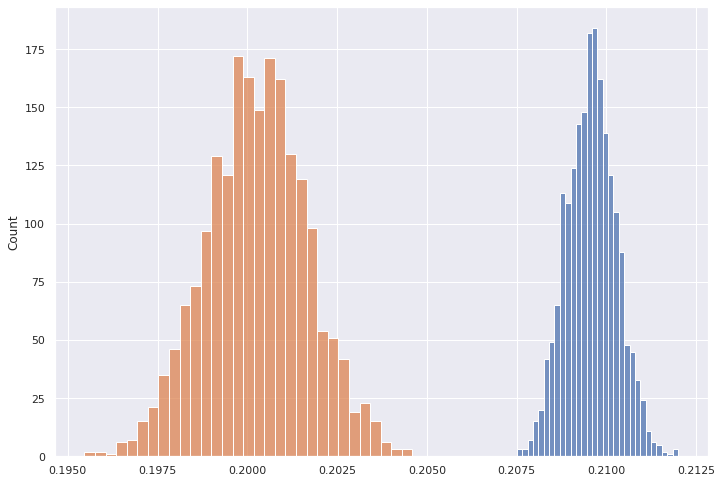

In [60]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
likes1 = df[df.exp_group == 1].likes.to_numpy()
views1 = df[df.exp_group == 1].views.to_numpy()
likes2 = df[df.exp_group == 2].likes.to_numpy()
views2 = df[df.exp_group == 2].views.to_numpy()
ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)
sns.histplot(ctr1)
sns.histplot(ctr2)

*Рис2. Гистограммы распределений глобальных CTR для групп 1 и 2*

По данному графику видно, что в одной из групп глобальный CTR выше, чем в другой группе

<Axes: ylabel='Count'>

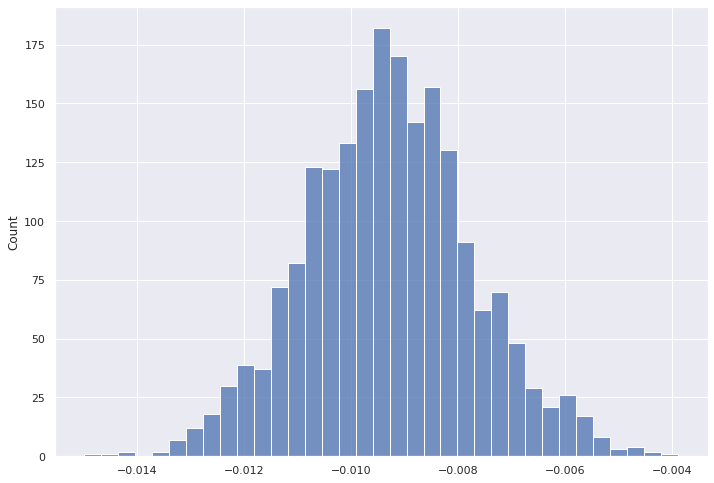

In [17]:
#Визуализируем разницу между глобальными CTR
sns.histplot(ctr2 - ctr1)

*Рис3. Гистограмма распределения разницы в глобальных CTR для групп 1 и 2*

Гистограмма разности не пересекает 0, что подтверждает предположение, что CTR в двух группах различается. Разница ненулевая, отрицательная. <br>
Таким образом, с помощью метода построения псевдовыборок пуассоновским бутстрепом доказано, что группа 2, пользователи, которым показали новый алгоритм, имеют худший результат CTR по сравнению с контрольной группой 1.

### Проведём t-тест и тест Манна-Уитни поверх бакетного преобразования

In [19]:
q = """
SELECT exp_group, bucket,
  sum(likes)/sum(views) as bucket_ctr,
  quantileExact(0.9)(ctr) as ctr9
FROM (SELECT exp_group,
      xxHash64(user_id)%50 as bucket,
      user_id,
      sum(action = 'like') as likes,
      sum(action = 'view') as views,
      likes/views as ctr
  FROM {db}.feed_actions
  WHERE toDate(time) between '2026-02-27' and '2026-03-05'
      and exp_group in (1,2)
  GROUP BY exp_group, bucket, user_id)
GROUP BY exp_group, bucket
"""
df = pandahouse.read_clickhouse(q, connection=connection)

In [21]:
#тест Манна-Уитни
stats.mannwhitneyu(df[df.exp_group == 1].bucket_ctr,
                  df[df.exp_group == 2].bucket_ctr,
                  alternative = 'two-sided')

MannwhitneyuResult(statistic=1997.0, pvalue=2.6576427804010095e-07)

Тест Манна-Уитни показал статистически значимое различие в CTR между двумя группами, p-value < 0.05.

Text(0.5, 1.0, 'CTR в бакетах группы 2')

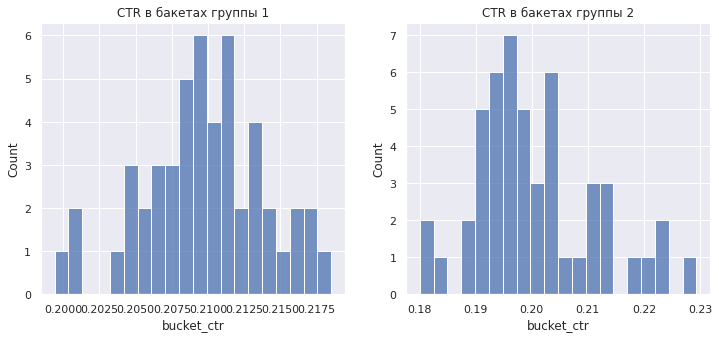

In [33]:
#Посмотрим на распределение метрики внутри бакетов
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Гистограмма распределения CTR в бакетах группы 1
sns.histplot(df[df.exp_group == 1].bucket_ctr, bins=20, ax=axes[0])
axes[0].set_title("CTR в бакетах группы 1")

# Гистограмма распределения CTR в бакетах группы 2
sns.histplot(df[df.exp_group == 2].bucket_ctr, bins=20, ax=axes[1])
axes[1].set_title("CTR в бакетах группы 2")

*Рис4. Гистограмма распределения метрики внутри бакета в группах 1 и 2*

В целом, распределения похожи на нормальные, можно провести t-тест

In [26]:
stats.ttest_ind(df[df.exp_group == 1].bucket_ctr,
                  df[df.exp_group == 2].bucket_ctr,
                  equal_var = False)

Ttest_indResult(statistic=5.614819358149381, pvalue=4.592644937473873e-07)

T-тест также показал значимое различие в двух группах, p-value<0.05. 

Таким образом, с помощью статистических тестов поверх бакетного преобразования показаны значимые различия метрики CTR в контрольной группе пользователей 1 и группе пользователей 2, которые взаимодействовали с новым алгоритмом предложения постов. 

<Axes: xlabel='bucket_ctr', ylabel='Count'>

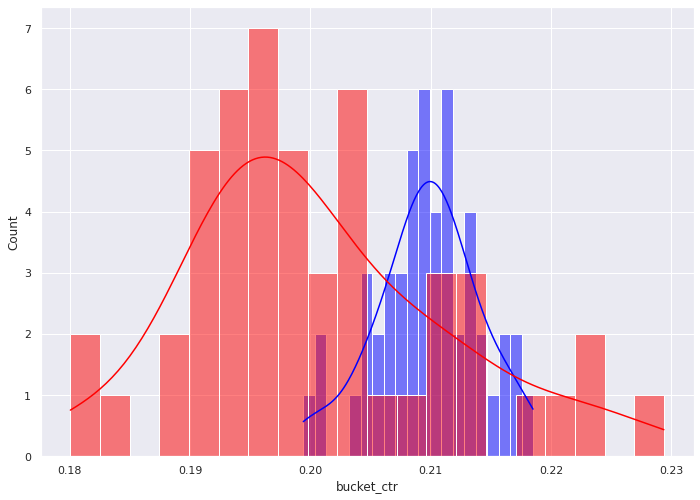

In [36]:
sns.histplot(df[df.exp_group == 1].bucket_ctr, color='blue',  bins=20, kde=True, alpha=0.5)
sns.histplot(df[df.exp_group == 2].bucket_ctr, color='red',  bins=20, kde=True, alpha=0.5)

*Рис5. Гистограмма распределений внутрибакетных CTR для группы 1(синий цвет) и группы 2(красный цвет)*

График выше подтвержает доказательство, что между группами 1 и 2 существует различие. Распределение бакетных CTR в экспериментальной группе 2 находится левее, что значит, что данная метрика имеет более низкие значения, чем в контрольной группе 1. Таким образом, новый алгоритм не привёл к увеличению CTR.

### Построим гистограмму распределений поюзерных ctr в двух группах

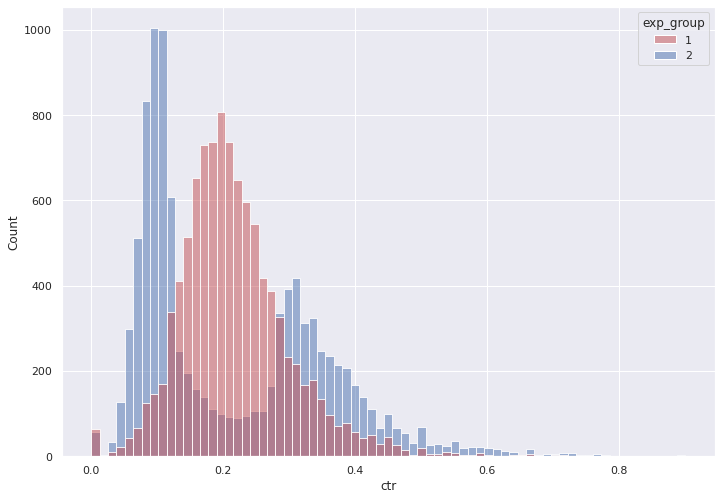

In [5]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
groups = sns.histplot(data = df,
              x='ctr',
              hue='exp_group',
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

*Рис6. Гистограмма распределения CTR для групп пользователей 1 и 2*

### Почему тесты сработали именно так? 


#### Подведём итоги.

Мы сравнили показатели СTR в группах 1 и 2 следующими методами:
1) Проанализировали различия в CTR в группах t-тестом. Различия незначимы. <br>
2) Проанализировали различия в CTR тестом Манна-Уитни. Различия значимы.<br>
3) Выполнили t-тест на сглаженном CTR. Различия незначимы.<br>
4) Применили Пуассоновский бутстреп для подсчета разницы в CTR. Выявили различия. <br>
5) Провели t-тест поверх бакетного преобразования. Различия значимы.<br>
6) Провели тест Манна-Уитни поверх бакетного преобразования. Различия значимы.<br>

Отметим, что t-тесты, проведённые на значениях поюзерных CTR и сглаженных CTR не показали различий между группами по следующим причинам: <br>
1) Т-тест подразумевает нормальные (или близкие к нормальному) распределения метрик. <br>
2) Результаты т-теста показывают, есть ли статистически значимое различие в средних показателях в двух группах.<br>

Чтобы ответить на вопрос, почему Т-тест не показал значимые различия в поюзерных CTR и сглаженных CTR в нашем конкретном случае, следует взглянуть на график распределения CTR выше (рис 6), и также обратиться к распределениям сглаженных CTR в разделе "Выполним t-тест на сглаженном ctr (α=5)" (Рис1) .<br>
На гистограммах мы видим, что и распределения CTR в группе 2 (красный цвет) на графике выше, и распределения сглаженных CTR (нижняя панель на рис1) очень отличаются от нормального, имеют 2 "горба", имеют много отклонений от среднего. <br>
По этой причине t-тесты на наших результатах сработали некорректно.
<br>
Также, t-тест не выявил различия между группами, так как он сравнивает средние CTR по двум группам, а различий в средних в нашем случае, практически, нет.<br>
Данное утверждение подтверждает график выше, и рассчёты в разделе "Сравним CTR в двух группах t-тестом"

Непараметрический тест Манна-Уитни не так чувствителен к нормальности распределения, как t-тест.Таким образом, оценка, полученная с помощью теста Манна-Уитни в нашем случае более надёжна, чем результаты t-теста <br>
Тест Манна-Уитни показал значимые различия показателей в двух группах. 

Также, метод Пуассоновского бутстрепа для подсчета разницы в CTR и бакетное преобразование оказались более чувствительными и подходящими тестами в нашем случае, чем классический t-тест. Оба теста показали значимую разницу в метриках между группами.

#### Опишите потенциальную ситуацию, когда такое изменение могло произойти. 
По результатам анализа, новый алгоритм не показал увеличения CTR, как этого ожидалось. Более того, пользователи из группы 2, которые взаимодействовали с новым алгоритмом рекомендации буквально "разделились" на две подгруппы внутри этой выборки, как можно видеть на рис6. У части пользователей произошло увеличение CTR по сравнению с контрольной группой (правый горб), значит, алгоритм пользователям понравился, и они ставили лайки более охотно на посты, предложенные этим новым алгоритмом. Алгоритм сработал как предполагалось.<br>
Однако, для другой части пользователей CTR упал, что означает, что посты, которые предлагал им новый алгоритм, меньше отмечались лайками и пользователям меньше нравились. Также нельзя исключить технические неполадки, привнесённые новым алгоритмом. <br>
Таким образом, новый алгоритм привёл к улучшению метрик только для части пользователей, для другой он показатели CTR ухудшил<br><br>
#### Напишите рекомендацию, будем ли мы раскатывать новый алгоритм на всех новых пользователей или все-таки не стоит.
Учитывая всё вышеописанное, показанное негативное изменение CTR, вызванное внедрением нового алгоритма, заключим, что на данном этапе раскатывать новый алгоритм на всех юзеров пока не стоит.<br>
В дальнейщем, возможно, следует проанализировать, что объдиняет пользователей из группы 2, у которых упал CTR, и если удастся найти причину падения метрики, учесть данную находку на будущее и снова провести A/B тестирование, если этот недочёт удастся исправить. Возможно, результаты нового теста покажут улучшение метрик в нужную нам сторону, новый алгорим будет внедрен, что положительно скажется на бизнесе.